## Revisiting the LSTM

In [1]:
### importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### importing the key
load_dotenv('../keys.txt')
key = os.getenv('key')

### Defining the functions and working with them

In [3]:
### targeting only the features ['close', 'high', 'low' and 'open']
features_to_target = ['close', 'high', 'low', 'open']

In [4]:
### function to load the stock price
def load_stock_price(symbol, features_to_target) : 

    df = pdr.get_data_tiingo(symbol, api_key = key)
    df = df[features_to_target].reset_index(drop = True)

    return df

In [5]:
stock_boeing = load_stock_price('BA', features_to_target)
stock_boeing.tail()

,close,high,low,open
1250,231.33,235.450,229.390000,233.00
1251,230.72,231.330,227.070000,231.05
1252,224.11,230.255,221.150000,230.22
1253,229.03,229.550,224.612027,225.90
1254,227.38,231.510,227.260000,230.40


In [6]:
stock_apple = load_stock_price('AAPL', features_to_target)
stock_apple.tail()

,close,high,low,open
1250,267.61,268.36,265.07,266.090
1251,270.71,273.23,268.66,272.335
1252,270.17,271.04,267.04,267.550
1253,271.35,276.00,268.14,270.500
1254,280.14,287.22,278.37,278.855


In [7]:
### function to plot the graphs for the scaled and non scaled data as the comparison
def plot_graphs(df, df_scaled = None) : 

    if df_scaled is not None : 

        for column in df.columns : 
                
            plt.figure(figsize = (8, 4))
            plt.subplot(1, 2, 1)
            plt.title(f"Before scaling :  {column}")
            plt.plot(df[column])
            plt.subplot(1, 2, 2)
            plt.title(f"After scaling :  {column}")
            plt.plot(df_scaled[column])


    else : 
        
        for column in df.columns : 
            plt.figure(figsize = (6, 4))
            plt.title(column)
            plt.plot(df[column])

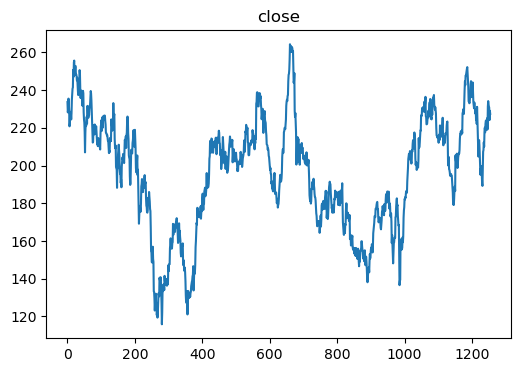

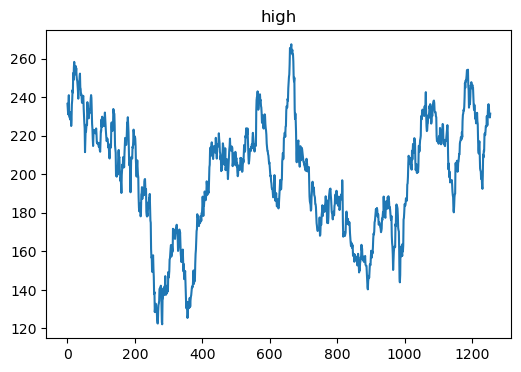

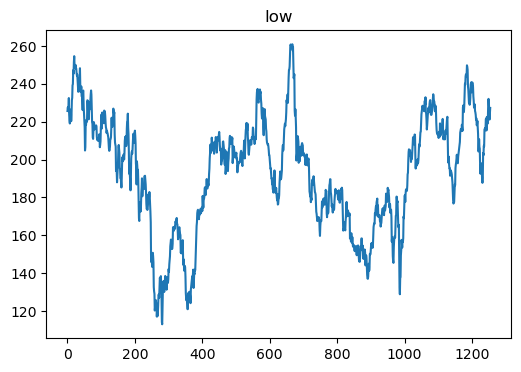

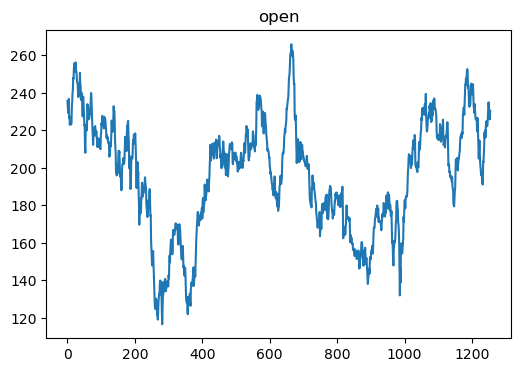

In [8]:
### plotting the graphs for the 'stock_boeing'
plot_graphs(stock_boeing)

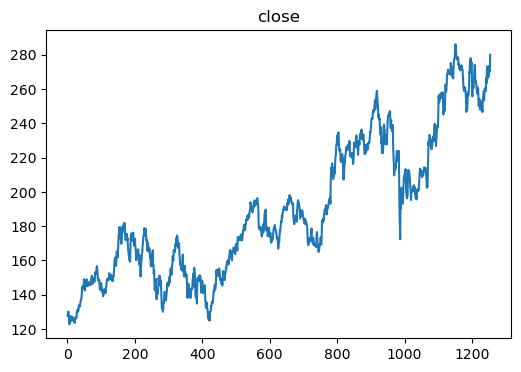

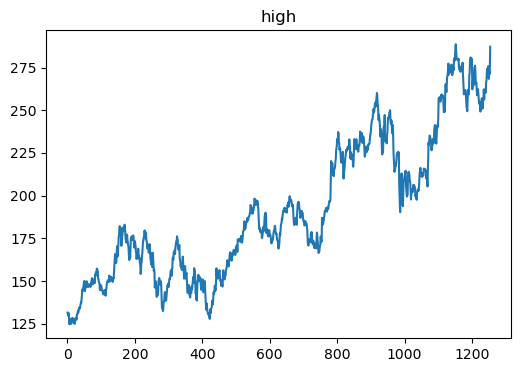

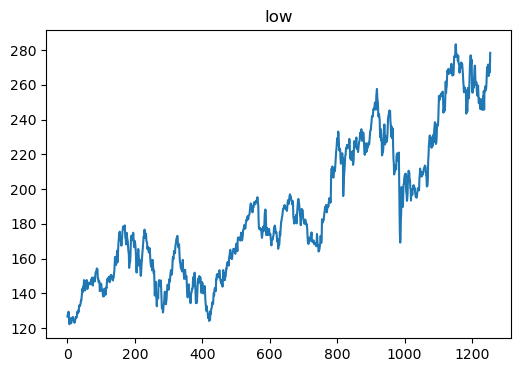

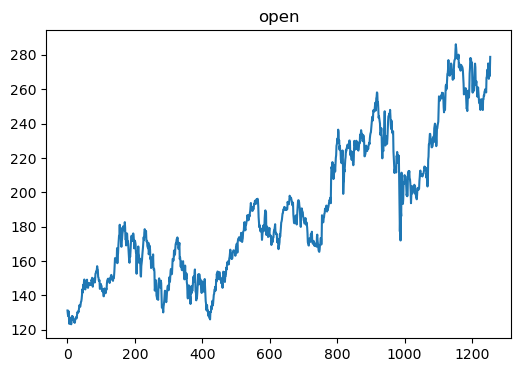

In [9]:
### plotting the graphs for the 'stock_apple'
plot_graphs(stock_apple)

In [10]:
### function to scale the data
def scale_data(df, scaler) : 

    df_scaled = scaler.fit_transform(df)
    df_scaled = pd.DataFrame(df_scaled, columns = df.columns)

    return df_scaled

In [11]:
### loading the scaler from the library
from sklearn.preprocessing import MinMaxScaler
scaler_apple = MinMaxScaler(feature_range = (0, 1))
scaler_boeing = MinMaxScaler(feature_range = (0, 1))

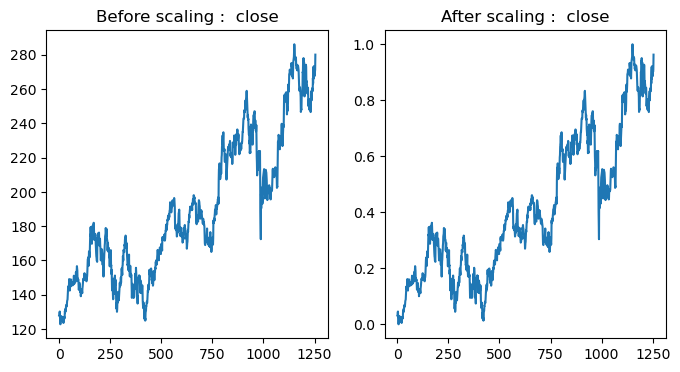

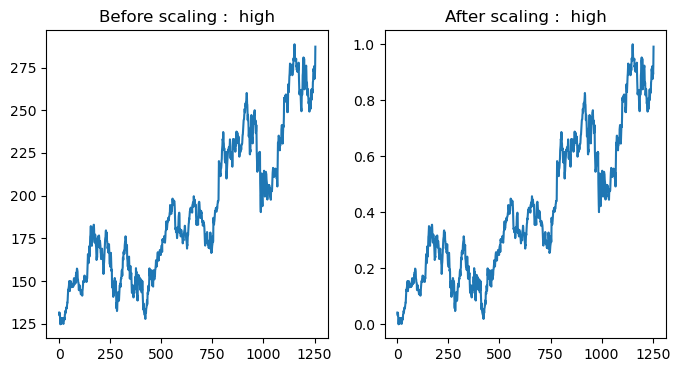

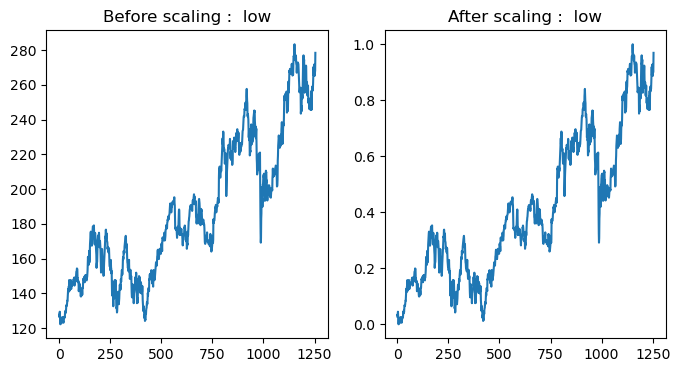

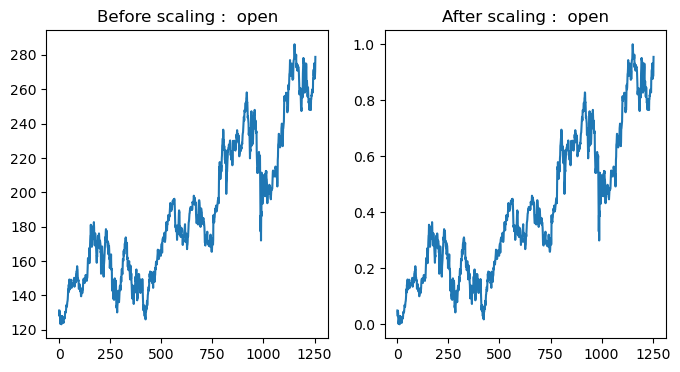

In [12]:
### scaling the data 'stock_apple' and the graphs for the comparison
stock_apple_scaled = scale_data(stock_apple, scaler = scaler_apple)
plot_graphs(stock_apple, stock_apple_scaled)

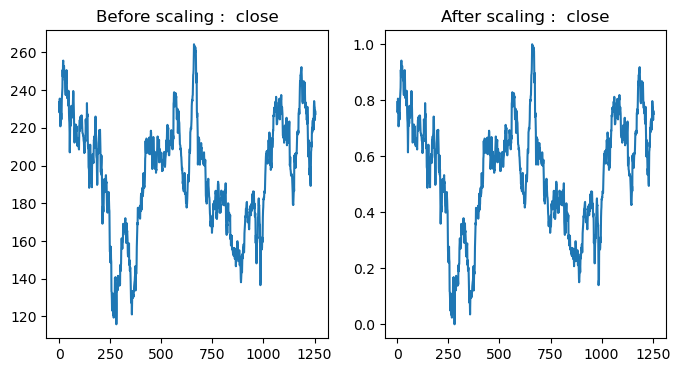

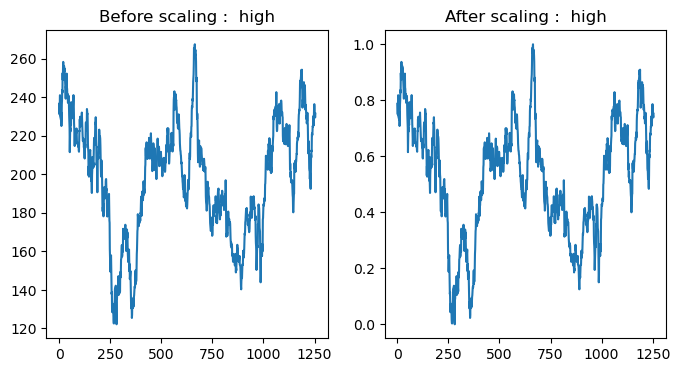

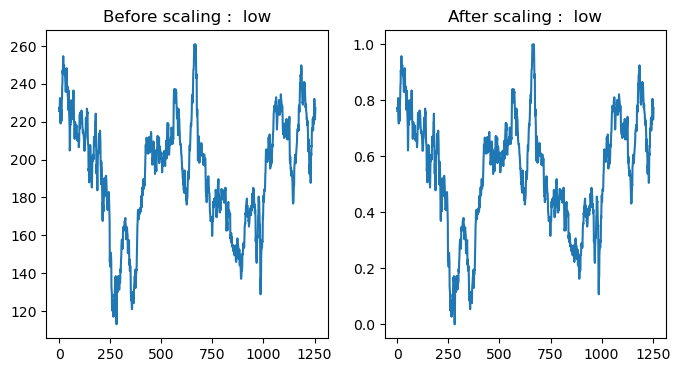

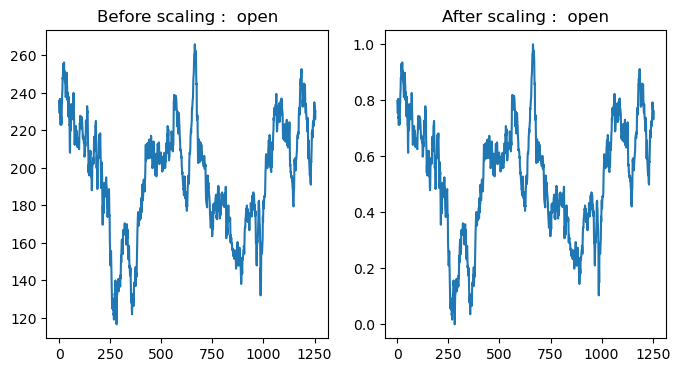

In [13]:
### scaling the data 'stock_boeing' and the graphs for the comparison
stock_boeing_scaled = scale_data(stock_boeing, scaler = scaler_boeing)
plot_graphs(stock_boeing, stock_boeing_scaled)

In [14]:
### importing the train test split library
from sklearn.model_selection import train_test_split

In [15]:
### function to create the sequences train and test sequences
def create_sequences(df, number_of_days) : 
    X, y = [], []

    for i in range(len(df) - number_of_days) : 

        X.append(df.iloc[i : i + number_of_days])
        y.append(df.iloc[i + number_of_days])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    print(f"{X_train.shape} :: {y_train.shape} \n{X_test.shape} :: {y_test.shape}")

    return X_train, X_test, y_train, y_test

In [16]:
### creating seuqnces for the apple stock price (90 days sequences)
X_train_apple, X_test_apple, y_train_apple, y_test_apple = create_sequences(stock_apple_scaled, number_of_days = 90)

(873, 90, 4) :: (873, 4) 
(292, 90, 4) :: (292, 4)


In [17]:
### creating seuqnces for the boeing stock price (90 days sequences)
X_train_boeing, X_test_boeing, y_train_boeing, y_test_boeing = create_sequences(stock_boeing_scaled, number_of_days = 90)

(873, 90, 4) :: (873, 4) 
(292, 90, 4) :: (292, 4)


In [18]:
### importing the libraries to create the sequeential model
import tensorflow
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional
from tensorflow.keras.models import Sequential

In [19]:
### function to create the model
def create_model(days) : 

    model = Sequential([
        LSTM(100, return_sequences = True, input_shape = (days, 4)),
        Dropout(0.33),
        Bidirectional(LSTM(200)),
        Dropout(0.21),
        Dense(4, activation = 'linear')
    ])
    model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])
    
    model.summary()

    return model

In [20]:
### crate the model for the 'stock_apple' 
model_apple = create_model(90)

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400)            │       481,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,204 (2.00 MB)

 Trainable params: 525,204 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
### creating the model for the 'stock_boeing'
model_boeing = create_model(90)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 90, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 400)            │       481,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,204 (2.00 MB)

 Trainable params: 525,204 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

### model_apple training and testing

In [22]:
### training of the 'model_apple'
model_apple.fit(X_train_apple, y_train_apple, batch_size = 32, epochs = 40, verbose = 1)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0525 - mse: 0.0525
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0057 - mse: 0.0057
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.0037 - mse: 0.0037
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0039 - mse: 0.0039
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0035 - mse: 0.0035
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0032 - mse: 0.0032
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0035 - mse: 0.0035
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0039 - mse: 0.0039
Epoch 9/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0028 - mse: 0.0028
Epoch 10/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0026 - mse: 0.0026
Epoch 11/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - loss: 0.0025 - mse: 0.0025
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0029 - mse: 0.0029
Epoch 13/40
28/28 ━━━━━━━

In [23]:
### predictions on the 'X_test_apple' 
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_apple

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


array([[0.6102797 , 0.6050086 , 0.6094822 , 0.612215  ],
       [0.11249141, 0.10768609, 0.1026624 , 0.10925664],
       [0.4881456 , 0.48431388, 0.48270404, 0.48954368],
       ...,
       [0.268342  , 0.25907236, 0.26151574, 0.26479292],
       [0.13820769, 0.13194528, 0.12912263, 0.1348592 ],
       [0.31561962, 0.30580938, 0.31047004, 0.31220445]], dtype=float32)

In [24]:
### shape checking
y_pred_apple.shape

(292, 4)

In [25]:
### inverse scaling the both
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

In [26]:
### checking the y_pred_apple
y_pred_apple

array([[222.5019 , 223.84932, 220.40712, 222.97554],
       [141.15335, 142.29837, 138.78378, 140.9732 ],
       [202.54276, 204.05779, 199.98949, 202.9752 ],
       ...,
       [166.62245, 167.12268, 164.36711, 166.33183],
       [145.3559 , 146.27638, 143.0452 , 145.14745],
       [174.34856, 174.78662, 172.2512 , 174.06181]], dtype=float32)

In [27]:
### y_test_apple
y_test_apple

array([[217.9   , 223.81  , 217.68  , 221.67  ],
       [137.44  , 143.422 , 137.325 , 142.13  ],
       [207.82  , 210.1865, 206.1401, 206.665 ],
       ...,
       [174.61  , 174.84  , 172.31  , 174.01  ],
       [150.04  , 153.59  , 148.5613, 152.215 ],
       [174.83  , 175.35  , 171.43  , 171.73  ]])

In [28]:
### functions to plot the metrices and the graphs to check the model's performances
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
def metrices_and_graphs(y_test, y_pred) : 

    print(f"mean_absolute_error : {mean_absolute_error(y_test, y_pred)}")
    print(f"root_mean_squared_error : {root_mean_squared_error(y_test, y_pred)}")
    print(f"mean_squared_error : {mean_squared_error(y_test, y_pred)}")

    plt.figure(figsize = (12, 4))

    #----------Plot to see the trend made by model
    plt.subplot(1, 3, 1)
    plt.plot(y_pred, label = 'Predicted')
    plt.plot(y_test, label = 'Actual')

    #----------Actual vs Predicted points
    plt.subplot(1, 3, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)

    #--------- Best fit line
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)
    plt.show()

mean_absolute_error : 3.43586137118405
root_mean_squared_error : 4.376632442270439
mean_squared_error : 19.154911534734104


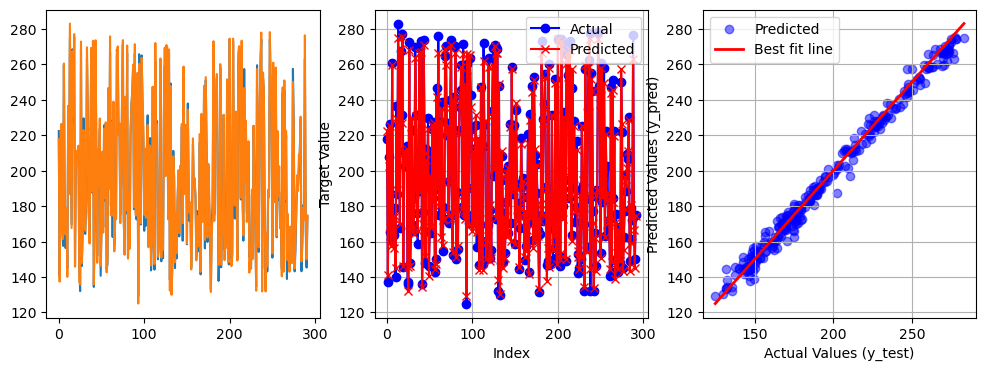

mean_absolute_error : 3.2108648210917425
root_mean_squared_error : 4.232178536908032
mean_squared_error : 17.91133516826501


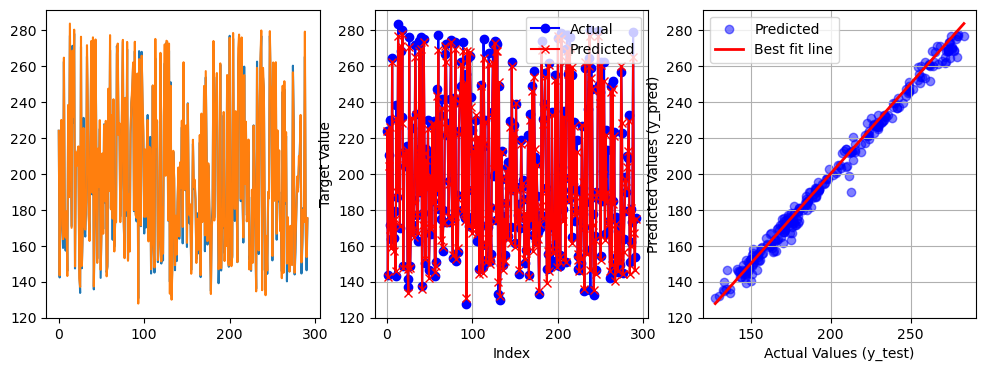

mean_absolute_error : 3.2021119543624246
root_mean_squared_error : 4.030608779591458
mean_squared_error : 16.24580713411974


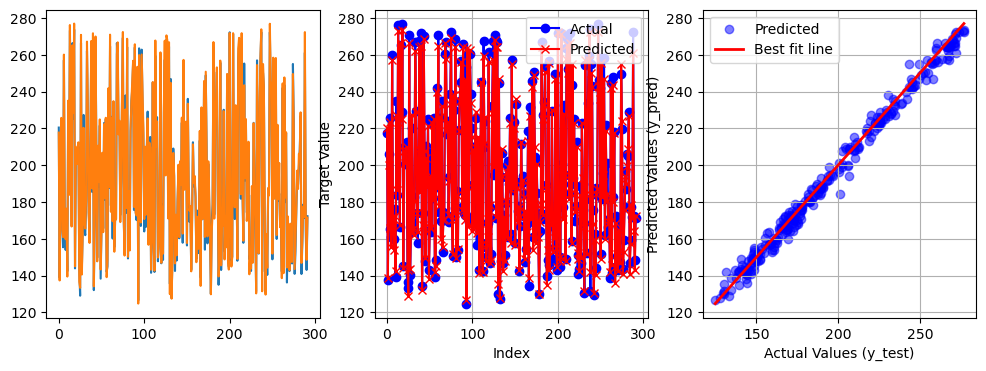

mean_absolute_error : 2.712451459910771
root_mean_squared_error : 3.6925922545584573
mean_squared_error : 13.63523755842511


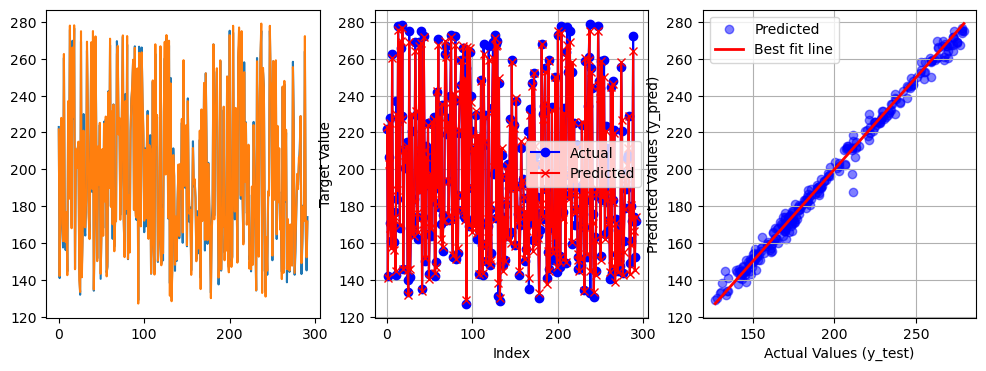

In [29]:
### checking the metrices and graphs
for i in range(0, 4) : 
    metrices_and_graphs(y_test_apple[:, i], y_pred_apple[:, i])

### model_boeing training and testing

In [30]:
### training the model
model_boeing.fit(X_train_boeing, y_train_boeing, batch_size = 32, epochs = 40, verbose = 1)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss: 0.0712 - mse: 0.0712
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0074 - mse: 0.0074
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0065 - mse: 0.0065
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0058 - mse: 0.0058
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0064 - mse: 0.0064
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0050 - mse: 0.0050
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0053 - mse: 0.0053
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0044 - mse: 0.0044
Epoch 9/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0040 - mse: 0.0040
Epoch 10/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0039 - mse: 0.0039
Epoch 11/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0038 - mse: 0.0038
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0038 - mse: 0.0038
Epoch 13/40
28/28 ━━━━━━━

In [31]:
### predicting the y_pred_boeing
y_pred_boeing = model_boeing.predict(X_test_boeing)
y_train_boeing

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


array([[0.55029985, 0.51861025, 0.54706654, 0.52813128],
       [0.27477933, 0.24162367, 0.26927238, 0.26985934],
       [0.6499562 , 0.63508772, 0.66837977, 0.64728734],
       ...,
       [0.21191294, 0.22703818, 0.23065999, 0.24748828],
       [0.0981066 , 0.0629515 , 0.10035164, 0.07890154],
       [0.4781349 , 0.44788442, 0.46186097, 0.44695244]])

In [32]:
### inverse scaling the datasets
y_pred_boeing = scaler_boeing.inverse_transform(y_pred_boeing)
y_test_boeing = scaler_boeing.inverse_transform(y_test_boeing)

mean_absolute_error : 4.011420065474838
root_mean_squared_error : 5.166168731809173
mean_squared_error : 26.6892993655228


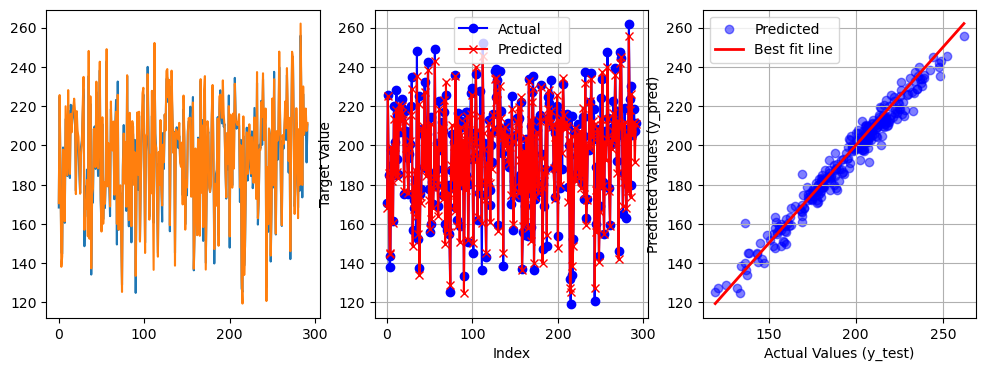

mean_absolute_error : 3.4401325592877114
root_mean_squared_error : 4.5384109400944315
mean_squared_error : 20.59717386116882


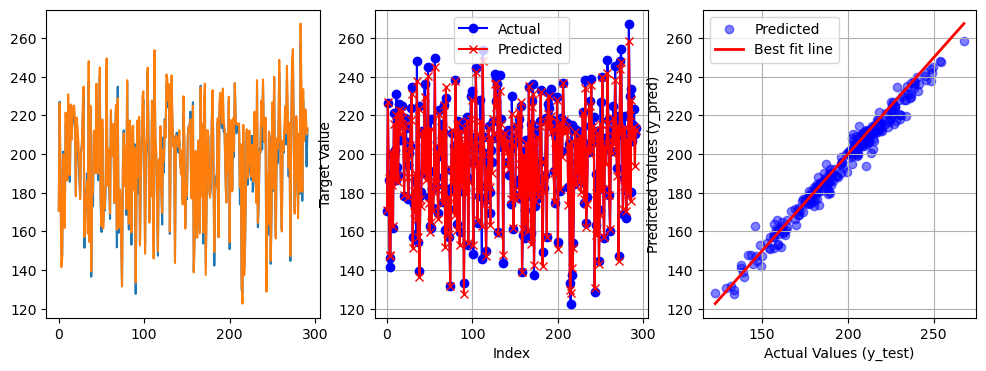

mean_absolute_error : 3.8764223032076064
root_mean_squared_error : 4.900950973084754
mean_squared_error : 24.019320440580398


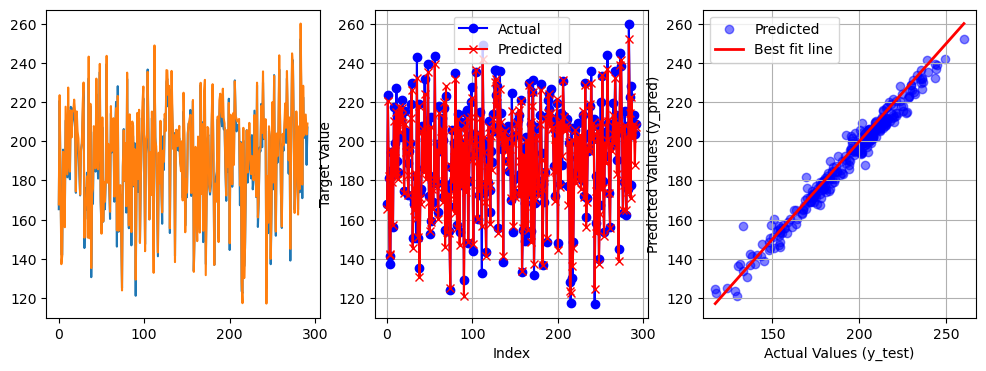

mean_absolute_error : 3.577178663488936
root_mean_squared_error : 4.3858617556122885
mean_squared_error : 19.235783339342504


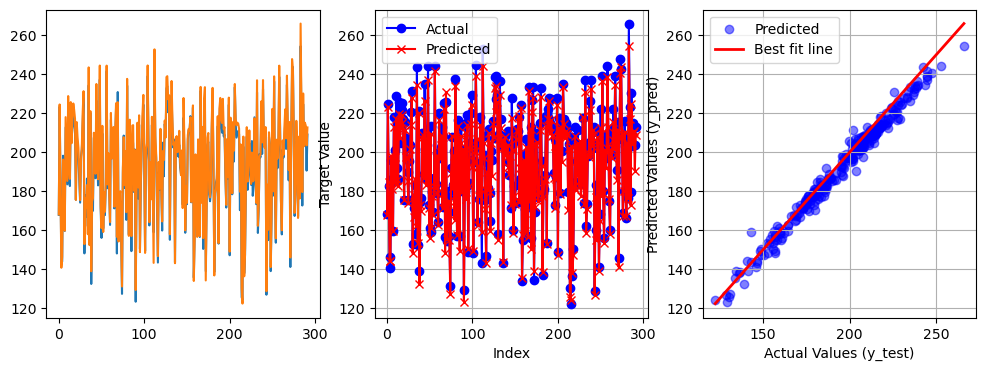

In [33]:
### checking the metrics and the graphs
for i in range(0, 4) : 
    metrices_and_graphs(y_test_boeing[:, i], y_pred_boeing[:, i])

### new predictions

In [42]:
future_days = 60
last_window = stock_apple_scaled[- future_days : ]
last_window = np.array(last_window)
last_window = np.expand_dims(last_window, axis = 0)

In [43]:
last_window.shape

(1, 60, 4)

In [69]:
future_preds = []

for _ in range(future_days) : 

    next_pred = model_apple.predict(last_sequence)
    future_preds.append(next_pred[0, :])

    next_pred_reshaped = np.expand_dims(next_pred, axis = 0)

    last_sequence = np.concatenate(
        (last_sequence[:, 1 : , :], next_pred_reshaped), axis = 1
    )

future_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

[array([0.5342076 , 0.5450126 , 0.5121121 , 0.53040785], dtype=float32),
 array([0.50299555, 0.51166934, 0.48238835, 0.49931088], dtype=float32),
 array([0.49660832, 0.5025351 , 0.4788628 , 0.4933915 ], dtype=float32),
 array([0.5009448 , 0.5040322 , 0.4861503 , 0.49794063], dtype=float32),
 array([0.50971115, 0.5109141 , 0.49785957, 0.50708884], dtype=float32),
 array([0.5213379, 0.5213641, 0.5118702, 0.5194119], dtype=float32),
 array([0.53311414, 0.5319661 , 0.5254849 , 0.5316642 ], dtype=float32),
 array([0.5439099 , 0.5421411 , 0.53786916, 0.54310316], dtype=float32),
 array([0.55322117, 0.55134195, 0.54836947, 0.5532288 ], dtype=float32),
 array([0.5609015 , 0.55891645, 0.5567392 , 0.56160223], dtype=float32),
 array([0.5664911 , 0.5645569 , 0.5627273 , 0.56789565], dtype=float32),
 array([0.56994426, 0.56791794, 0.5663607 , 0.571834  ], dtype=float32),
 array([0.57155037, 0.56943494, 0.5680541 , 0.573788  ], dtype=float32),
 array([0.57126653, 0.56910104, 0.56780165, 0.57368314]

In [70]:
future_preds = np.array(future_preds)
future_preds.shape

(60, 4)

In [72]:
future_preds = scaler_apple.inverse_transform(future_preds)
future_preds

array([[210.0702 , 214.01117, 204.72566, 209.63771],
       [204.96953, 208.54353, 199.93864, 204.56764],
       [203.92572, 207.04572, 199.37085, 203.60255],
       [204.63438, 207.2912 , 200.5445 , 204.34424],
       [206.067  , 208.4197 , 202.43028, 205.83577],
       [207.96704, 210.13329, 204.6867 , 207.84492],
       [209.89151, 211.87181, 206.87935, 209.84254],
       [211.65576, 213.5403 , 208.87384, 211.70755],
       [213.1774 , 215.04906, 210.56491, 213.35843],
       [214.43253, 216.29112, 211.91284, 214.72363],
       [215.34598, 217.21603, 212.87723, 215.74971],
       [215.9103 , 217.7672 , 213.46239, 216.39183],
       [216.17276, 218.01595, 213.7351 , 216.7104 ],
       [216.12637, 217.96118, 213.69446, 216.6933 ],
       [215.83475, 217.70354, 213.3993 , 216.43436],
       [215.48882, 217.35315, 212.99753, 216.09583],
       [215.04509, 216.90482, 212.50543, 215.65033],
       [214.53671, 216.39334, 211.95798, 215.13516],
       [214.06017, 215.91406, 211.44225, 214.6